In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r"F:\Python\Deep-Learning-and-Computer-vision\Dataset\Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df.drop(columns=['RowNumber','CustomerId','Surname'])

In [7]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [8]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
x = df.drop(columns=['Exited'])
y = df['Exited']

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [13]:
x_train.shape

(8000, 11)

In [26]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [16]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [30]:
model = Sequential()
model.add(Dense(11, activation='relu', input_dim=11))
model.add(Dense(5,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

f:\Python\Deep-Learning-and-Computer-vision\deepenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198 (792.00 B)

 Trainable params: 198 (792.00 B)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [41]:
history = model.fit(x_train_scaled,y_train,epochs=10,validation_split=0.2)

Epoch 1/10


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8530 - loss: 0.3561 - val_accuracy: 0.8487 - val_loss: 0.3640
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8519 - loss: 0.3542 - val_accuracy: 0.8550 - val_loss: 0.3626
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8547 - loss: 0.3525 - val_accuracy: 0.8462 - val_loss: 0.3617
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8569 - loss: 0.3512 - val_accuracy: 0.8544 - val_loss: 0.3608
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8578 - loss: 0.3510 - val_accuracy: 0.8550 - val_loss: 0.3596
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8550 - loss: 0.3497 - val_accuracy: 0.8512 - val_loss: 0.3591
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8583 - loss: 0.3483 - val_accuracy: 0.8537 - val_loss: 0.3568
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8575 - loss: 0.3477 - val_accuracy: 0.8550 - val_

In [42]:
model.layers[0].get_weights()  #33 weights of first layer and 3 bias of hidden layer 

[array([[-1.26028314e-01, -2.40595073e-01,  3.90380949e-01,
         -4.11589801e-01, -1.65507048e-02,  2.84473170e-02,
         -7.33306929e-02,  3.71762276e-01,  3.16879928e-01,
         -1.31489560e-01,  2.36396864e-01],
        [ 3.42400402e-01, -7.86499858e-01, -6.86147273e-01,
          4.40397561e-01, -3.48794341e-01,  1.47877365e-01,
          6.25871778e-01,  3.57405603e-01,  9.86730978e-02,
          7.37994239e-02,  3.88479799e-01],
        [ 3.09857149e-02,  9.17828176e-03, -4.94407326e-01,
         -3.78482565e-02,  5.62437952e-01,  2.66536698e-02,
          1.51061304e-02, -1.43843114e-01, -2.81799614e-01,
         -8.77997205e-02, -4.80115525e-02],
        [-2.43032694e-01,  2.74418086e-01, -6.91685915e-01,
          3.91463399e-01, -5.06058455e-01,  1.72825217e-01,
         -5.06279647e-01,  3.75454366e-01, -2.00788975e-01,
         -4.28017676e-01, -2.11285144e-01],
        [ 4.36953872e-01, -2.29235783e-01, -2.46192496e-02,
          9.74418581e-01,  1.05195113e-01,  

In [43]:
y_log = model.predict(x_test_scaled)
y_pred = np.where(y_log>0.5,1,0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [44]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred, y_test))

0.8545


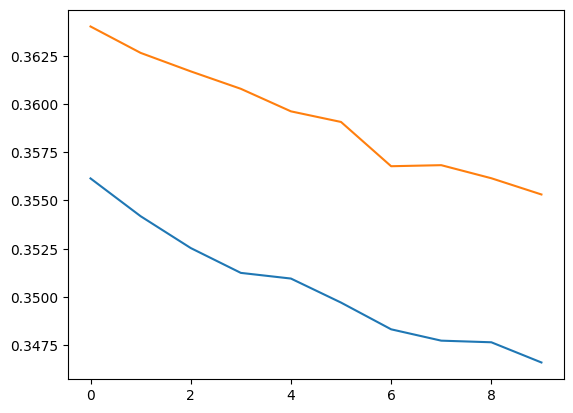

In [46]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

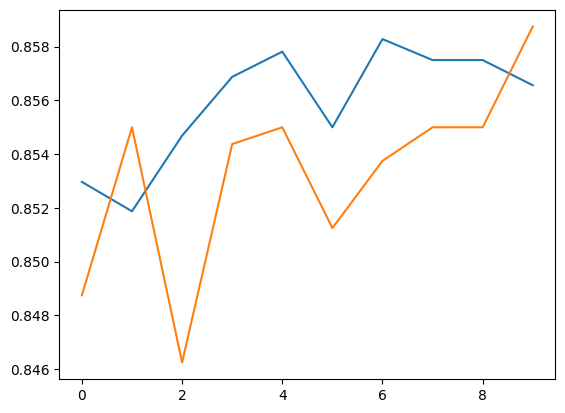

In [47]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])